# SECCHI/EUVI extension — maps, reprojection, J-maps, kinematics, deprojection

Extends `plot_SECCHI.ipynb`, reusing `difference_maps.py` and the `plot_jmap`
helpers unchanged (`load_channel`, `crop_to_roi`, `make_slit_grid`,
`sample_map_along_slit`, the point-and-click tracer and the kinematics functions).

1. EUVI maps + running difference/ratio, cropped on the central eruption.
2. AIA → EUVI ROI reprojection (four corners + spherical-screen).
3. Radial-slit J-maps + kinematics (auto ridge **and** point-and-click).
4. Great-arc J-maps (true surface distance) and comparison.
5. Plane-of-sky speed deprojection from the source longitude.

In [29]:
# Interactive backend is required for the manual feature tracing further down.
%matplotlib widget
# Non-interactive alternative (no clicking): %matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import os
import glob
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as colors

from scipy.ndimage import map_coordinates
from scipy.signal import savgol_filter

import astropy.units as u
from astropy.coordinates import SkyCoord

import sunpy
import sunpy.map
import sunpy.sun.constants as const
from sunpy.time import parse_time

from tqdm import tqdm

# Quieten SunPy's logger so the long sequence loops stay readable.
sunpy.log.setLevel(logging.WARNING)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'


def save_fig(fig, savepath, dpi=300):
    """Publication export: tight bounding box, minimal whitespace. No-op if savepath is None."""
    if savepath is not None:
        fig.savefig(savepath, dpi=dpi, bbox_inches='tight', pad_inches=0.02)

## Configuration

The only block to edit. Everything downstream reads from these names, so a slit,
feature, channel, region, or time window is changed here rather than inline.


In [75]:
# --- Data location and event --------------------------------------------------
DATA_DIR    = '/home/mnedal/data'
DATE        = '2025-10-06'
CHANNELS    = {'R': 211, 'G': 193, 'B': 171}   # colour -> AIA channel [Angstrom]

# Regions of interest in helioprojective arcsec (left/right/bottom/top).
ROIS = {
    'west_limb': dict(left=800,  right=1210, bottom=-300, top=300),
    'central':  dict(left=-120, right=500,  bottom=-200, top=400),
}
REGION = 'central'                              # key into ROIS

# --- Running-ratio RGB construction -------------------------------------------
RATIO_LAG        = 12                           # frame / frame-(LAG); LAG x cadence = baseline
RGB_METHOD       = 'powernorm'                  # 'percentile' | 'fixed' | 'powernorm'
RGB_SCALE_KWARGS = dict(gamma=0.5, lo=0.5, hi=2)

# --- Time sequence used to build the J-plots ----------------------------------
SEQ_START = '2025-10-06T08:40:00'
SEQ_END   = '2025-10-06T09:05:00'
SEQ_FREQ  = '12s'

# --- Slit geometry (radial fan from one origin) -------------------------------
SLIT_START_XY      = (150, 100)                 # origin in arcsec (Tx, Ty)
SLIT_ANGLES_DEG    = np.arange(-90, 10, 10)     # CCW from solar West
SLIT_LENGTH_ARCSEC = 300
N_SAMPLES          = 300                         # points sampled along each slit

# --- J-plot display window ----------------------------------------------------
DISTANCE_UNIT = 'Mm'                            # 'Mm' (required for kinematics) or 'arcsec'
JPLOT_TLIM    = ('2025-10-06T08:40:00', '2025-10-06T08:55:00')
JPLOT_DLIM    = (30, 100)                       # distance window in DISTANCE_UNIT
JPLOT_CMAP    = 'Greys_r'

# --- Feature tracing ----------------------------------------------------------
CHANNEL    = 'G'                               # channel the J-plots are traced on
FEATURE_ID = 'front_00'                        # label for the traced feature
N_REPEATS  = 5                                 # repeated manual traces per slit

# --- Kinematics smoothing -----------------------------------------------------
SAVGOL_WINDOW    = 5
SAVGOL_POLYORDER = 2

# --- Reference frame for the slit-overlay preview -----------------------------
REF_DATETIME = '2025-10-06T08:47:00'           # nearest sequence frame is used

# --- Plot display / export ----------------------------------------------------
SHOW_TITLES = True                             # draw a title on every plot
SAVE_FIGS   = True                             # export publication-quality PNGs
FIG_DIR     = './plots'                        # directory for exported figures
FIG_DPI     = 300                              # export resolution

# --- Output -------------------------------------------------------------------
OUTPUT_DIR = './outputs'

year, month, day = DATE.split('-')
print(f'Event {DATE} | region {REGION} | tracing channel {CHANNEL} ({CHANNELS[CHANNEL]} A)')

Event 2025-10-06 | region central | tracing channel G (193 A)


## Core: load channels and build running-ratio RGB maps


In [31]:
def load_channel(channel, date, data_dir):
    """Load a full-day AIA level-1.5 sequence for one channel as a MapSequence."""
    y, m, d = date.split('-')
    files = sorted(glob.glob(
        f'{data_dir}/AIA/{channel}A/highres/lv15/'
        f'aia.lev15.{channel}A_{y}_{m}_{d}T*_lev15*.fits'))
    if not files:
        raise FileNotFoundError(f'No files for {channel} A on {date}.')
    return sunpy.map.Map(files, sequence=True)


def running_ratio_map(sequence, target_time, lag=1, denom_floor=1.0):
    """Ratio of the frame nearest target_time to the frame `lag` steps earlier."""
    t   = parse_time(target_time)
    idx = int(np.argmin([abs(mp.date - t) for mp in sequence.maps]))
    if idx < lag:
        raise ValueError(f'Frame {idx} has no frame {lag} step(s) earlier.')
    cur, prev = sequence[idx], sequence[idx - lag]
    # NaN out near-zero/off-limb denominators so they map to black rather than blow up.
    denom = np.where(prev.data > denom_floor, prev.data, np.nan)
    rmap  = sunpy.map.Map(cur.data / denom, cur.meta)
    rmap.plot_settings['norm'] = colors.Normalize()  # avoid inherited-stretch repr crash
    return rmap, cur.date


def crop_to_roi(rmap, box):
    """Submap to an ROI given as left/right/bottom/top in arcsec."""
    frame = rmap.coordinate_frame
    bl = SkyCoord(box['left']  * u.arcsec, box['bottom'] * u.arcsec, frame=frame)
    tr = SkyCoord(box['right'] * u.arcsec, box['top']    * u.arcsec, frame=frame)
    return rmap.submap(bl, top_right=tr)


def scale_to_unit(data, method='percentile',
                  plo=0.5, phi=99.5, lo=0.5, hi=2.0, gamma=0.5):
    """Map a ratio array into [0, 1] for RGB display."""
    a = np.asarray(data, dtype=float)
    if method == 'percentile':
        vmin, vmax = np.nanpercentile(a, [plo, phi])
        out = (a - vmin) / (vmax - vmin)
    elif method == 'fixed':
        out = (a - lo) / (hi - lo)
    elif method == 'powernorm':
        out = colors.PowerNorm(gamma=gamma, vmin=lo, vmax=hi, clip=True)(a)
    else:
        raise ValueError("method must be 'percentile', 'fixed', or 'powernorm'.")
    return np.clip(np.nan_to_num(out, nan=0.0), 0, 1)


def build_rgb(r_map, g_map, b_map, method='percentile', **kw):
    """Stack three same-grid AIA ratio maps into an RGB array; G carries the WCS."""
    # Trim to the common shape as a guard against off-by-one grid mismatches.
    ny = min(m.data.shape[0] for m in (r_map, g_map, b_map))
    nx = min(m.data.shape[1] for m in (r_map, g_map, b_map))
    r = scale_to_unit(r_map.data[:ny, :nx], method, **kw)
    g = scale_to_unit(g_map.data[:ny, :nx], method, **kw)
    b = scale_to_unit(b_map.data[:ny, :nx], method, **kw)
    rgb = np.dstack([r, g, b])
    ref = sunpy.map.Map(g_map.data[:ny, :nx], g_map.meta)
    ref.plot_settings['norm'] = colors.Normalize()
    return rgb, ref

## Slit geometry

A fan of straight radial slits sharing one origin. Each slit is stored as a
two-point `SkyCoord` (start, end) in the reference map's frame.


In [32]:
def make_hpc_coord(x_arcsec, y_arcsec, map_obj):
    """SkyCoord at (x, y) arcsec in the coordinate frame of map_obj."""
    return SkyCoord(x_arcsec * u.arcsec, y_arcsec * u.arcsec,
                    frame=map_obj.coordinate_frame)


def make_slit(start_xy, angle_deg, length_arcsec, map_obj):
    """One straight slit from start_xy at angle_deg (CCW from solar West).

    Returns a two-point SkyCoord [start, end].
    """
    x0, y0 = start_xy
    angle_rad = np.deg2rad(angle_deg)
    x1 = x0 + length_arcsec * np.cos(angle_rad)
    y1 = y0 + length_arcsec * np.sin(angle_rad)
    start = make_hpc_coord(x0, y0, map_obj)
    end   = make_hpc_coord(x1, y1, map_obj)
    return SkyCoord([start, end])


def make_slit_grid(start_xy, angles_deg, length_arcsec, map_obj):
    """Build a dict of slits {('slit_NN'): {angle, start_xy, length, line}}."""
    slits = {}
    for i, angle in enumerate(angles_deg):
        slit_id = f'slit_{i + 1:02d}'   # 1-based numbering
        slits[slit_id] = {
            'angle_deg': angle,
            'start_xy': start_xy,
            'length_arcsec': length_arcsec,
            'line': make_slit(start_xy, angle, length_arcsec, map_obj),
        }
    return slits

## Sampling intensity along a slit and per-frame processing


In [33]:
def sample_map_along_slit(map_obj, slit_line, n_samples=300, order=1):
    """Interpolate map values along a slit.

    Returns (distances_arcsec, intensities, coords). Distances are measured from
    the slit start. `order` is the map_coordinates interpolation order
    (0 = nearest, 1 = linear).
    """
    start, end = slit_line[0], slit_line[1]

    x_vals = np.linspace(start.Tx.to_value(u.arcsec),
                         end.Tx.to_value(u.arcsec), n_samples)
    y_vals = np.linspace(start.Ty.to_value(u.arcsec),
                         end.Ty.to_value(u.arcsec), n_samples)

    coords = SkyCoord(x_vals * u.arcsec, y_vals * u.arcsec,
                      frame=map_obj.coordinate_frame)

    px, py = map_obj.world_to_pixel(coords)
    intensities = map_coordinates(
        map_obj.data.astype(float),
        [py.to_value(u.pix), px.to_value(u.pix)],
        order=order, mode='constant', cval=np.nan,
    )

    distances_arcsec = np.sqrt((x_vals - x_vals[0])**2 + (y_vals - y_vals[0])**2)
    return distances_arcsec, intensities, coords


def process_one_rgb_frame(sequences, target_time, channels, roi_box,
                          lag=12, method='powernorm', scale_kwargs=None):
    """Build one cropped running-ratio RGB frame from three channel sequences."""
    if scale_kwargs is None:
        scale_kwargs = {}

    ratio_maps, frame_times = {}, {}
    for colour in channels:
        ratio_maps[colour], frame_times[colour] = running_ratio_map(
            sequences[colour], target_time, lag=lag)

    cropped = {colour: crop_to_roi(ratio_maps[colour], roi_box) for colour in channels}
    rgb, ref_map = build_rgb(cropped['R'], cropped['G'], cropped['B'],
                             method=method, **scale_kwargs)

    return {
        'target_time': target_time,
        'frame_times': frame_times,
        'ratio_maps': ratio_maps,
        'cropped_maps': cropped,
        'rgb': rgb,
        'ref_map': ref_map,
    }


def trace_slits_for_frame(frame_result, slits, n_samples=300):
    """Sample every slit on every channel of one processed frame."""
    traces = {}
    for slit_id, slit in slits.items():
        traces[slit_id] = {
            'angle_deg': slit['angle_deg'],
            'start_xy': slit['start_xy'],
            'length_arcsec': slit['length_arcsec'],
            'channels': {},
        }
        for colour, mp in frame_result['cropped_maps'].items():
            distance, intensity, coords = sample_map_along_slit(
                mp, slit['line'], n_samples=n_samples)
            traces[slit_id]['channels'][colour] = {
                'distance_arcsec': distance,
                'intensity': intensity,
                'coords': coords,
            }
    return traces

## Process the full time sequence

Builds an RGB frame at every target time and traces all slits through each frame.
The slit grid is created once, on the first frame's reference map, and reused so
distances are consistent across the sequence.


In [34]:
def process_rgb_slit_sequence(sequences, target_times, channels, roi_box,
                              start_xy, angles_deg, length_arcsec,
                              lag=12, method='powernorm',
                              scale_kwargs=None, n_samples=300):
    """Process many frames and trace slits through all of them."""
    if scale_kwargs is None:
        scale_kwargs = {}

    results = {'frames': {}, 'traces': {}, 'slits': None, 'target_times': target_times}

    for target_time in tqdm(target_times, desc='Processing RGB/slit sequence'):
        frame = process_one_rgb_frame(
            sequences=sequences, target_time=target_time, channels=channels,
            roi_box=roi_box, lag=lag, method=method, scale_kwargs=scale_kwargs)

        if results['slits'] is None:
            results['slits'] = make_slit_grid(
                start_xy=start_xy, angles_deg=angles_deg,
                length_arcsec=length_arcsec, map_obj=frame['ref_map'])

        results['frames'][target_time] = frame
        results['traces'][target_time] = trace_slits_for_frame(
            frame_result=frame, slits=results['slits'], n_samples=n_samples)

    return results

## RGB preview with slit overlay


In [35]:
def plot_rgb_with_slits(rgb, ref_map, slits=None, title='',
                        slit_colour='red', slit_lw=1, label_offset_arcsec=15,
                        show_title=True, savepath=None, dpi=300):
    """Show an RGB frame, optionally overlaying slits labelled near their tips.

    Pass slits=None for a plain RGB preview.
    """
    fig = plt.figure(figsize=[7, 7])
    ax = fig.add_subplot(projection=ref_map)
    ax.imshow(rgb, origin='lower')
    ax.grid(False)

    if slits is not None:
        for slit_id, slit in slits.items():
            line = slit['line']
            ax.plot_coord(line, color=slit_colour, linestyle='-', lw=slit_lw, alpha=0.7)

            start, end = line[0], line[1]
            dx = end.Tx.to_value(u.arcsec) - start.Tx.to_value(u.arcsec)
            dy = end.Ty.to_value(u.arcsec) - start.Ty.to_value(u.arcsec)
            norm = np.hypot(dx, dy)
            ux, uy = (0, 0) if norm == 0 else (dx / norm, dy / norm)

            # Offset the label just beyond the slit tip along its own direction.
            label_coord = SkyCoord(
                (end.Tx.to_value(u.arcsec) + label_offset_arcsec * ux) * u.arcsec,
                (end.Ty.to_value(u.arcsec) + label_offset_arcsec * uy) * u.arcsec,
                frame=ref_map.coordinate_frame)

            slit_number = int(slit_id.split('_')[-1])       # slit_ids are already 1-based
            ax.text_coord(label_coord, slit_number, color=slit_colour,
                          fontsize=10, fontweight='bold', ha='center', va='center')

    if show_title:
        ax.set_title(title)
    ax.set_xlabel('Solar X [arcsec]')
    ax.set_ylabel('Solar Y [arcsec]')
    save_fig(fig, savepath, dpi=dpi)
    return fig, ax

## Build and plot a J-plot for one slit


In [36]:
def arcsec_to_Mm_factor(ref_map):
    """arcsec -> Mm using the map's observed solar radius (physical R_sun / R_sun_obs)."""
    rsun_obs_arcsec = ref_map.rsun_obs.to_value(u.arcsec)
    rsun_Mm = const.radius.to_value(u.Mm)
    return rsun_Mm / rsun_obs_arcsec


def build_jplot(results, slit_id, channel='G', distance_unit='Mm'):
    """Stack per-frame intensity traces into a [n_times, n_distances] J-plot array.

    Returns (jplot, times, distances, distance_label).
    """
    times = list(results['traces'].keys())
    rows = [results['traces'][t][slit_id]['channels'][channel]['intensity'] for t in times]
    jplot = np.asarray(rows)

    distances_arcsec = results['traces'][times[0]][slit_id]['channels'][channel]['distance_arcsec']

    if distance_unit == 'arcsec':
        distances = distances_arcsec
        distance_label = 'Distance along slit [arcsec]'
    elif distance_unit == 'Mm':
        ref_map = results['frames'][times[0]]['ref_map']
        distances = distances_arcsec * arcsec_to_Mm_factor(ref_map)
        distance_label = 'Distance along slit [Mm]'
    else:
        raise ValueError("distance_unit must be 'arcsec' or 'Mm'.")

    return jplot, times, distances, distance_label


def plot_jplot(results, slit_id, channel='G', distance_unit='Mm',
               xlim=None, ylim=None, vmin=None, vmax=None,
               percentile=(1, 99), cmap='RdYlBu_r',
               title=None, show_title=True, savepath=None, dpi=300):
    """Plot a distance--time J-plot for one slit/channel.

    Returns (fig, ax, jplot, times, distances).
    """
    jplot, times, distances, distance_label = build_jplot(
        results, slit_id=slit_id, channel=channel, distance_unit=distance_unit)

    time_nums = mdates.date2num(pd.to_datetime(times))
    if vmin is None or vmax is None:
        vmin, vmax = np.nanpercentile(jplot, percentile)

    fig, ax = plt.subplots(figsize=[8, 6])
    mesh = ax.pcolormesh(time_nums, distances, jplot.T, shading='auto',
                         cmap=cmap, vmin=vmin, vmax=vmax)

    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

    if xlim is not None:
        ax.set_xlim(*mdates.date2num(pd.to_datetime(list(xlim))))
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel('Time [UT]')
    ax.set_ylabel(distance_label)
    if show_title:
        ax.set_title(title if title is not None else f'{slit_id} | channel {channel}')
    fig.colorbar(mesh, ax=ax, pad=0.01, label='Running-ratio intensity')
    fig.autofmt_xdate()
    save_fig(fig, savepath, dpi=dpi)
    return fig, ax, jplot, times, distances

## Interactive feature tracing on a J-plot

Left-click to add points to the current trace; right-click to store it and reset
for the next repeat. After `n_repeats` stored traces the handler disconnects.
Repeats give a spread that becomes the standard error on the kinematics.


In [37]:
def collect_repeated_jplot_traces(fig, ax, slit_id, feature_id='front_00',
                                  n_repeats=5, storage=None, y_unit='Mm',
                                  marker='x', line_style='-', show_title=True):
    """Collect repeated manual traces of a moving feature on a J-plot.

    Storage layout: storage[slit_id][feature_id] = {'y_unit', 'repeats': [...]}.
    Pass an existing `storage` dict to accumulate across slits.
    """
    if storage is None:
        storage = {}
    storage.setdefault(slit_id, {})
    storage[slit_id].setdefault(feature_id, {'y_unit': y_unit, 'repeats': []})

    current_trace = {'x_time_num': [], 'x_time': [], 'y_distance': []}
    current_artists = []

    def update_title():
        """Show which repeat is in progress (or completion) in the J-plot title."""
        if not show_title:
            return
        done = len(storage[slit_id][feature_id]['repeats'])
        if done >= n_repeats:
            ax.set_title(f'{slit_id} | {feature_id} | {n_repeats}/{n_repeats} repeats done')
        else:
            ax.set_title(f'{slit_id} | {feature_id} | repeat {done + 1}/{n_repeats}')
        fig.canvas.draw_idle()

    def redraw_current_trace():
        nonlocal current_artists
        for artist in current_artists:
            artist.remove()
        current_artists = []

        x, y = current_trace['x_time_num'], current_trace['y_distance']
        if len(x) == 0:
            fig.canvas.draw_idle()
            return

        point_artist, = ax.plot(x, y, linestyle='None', marker=marker,
                                ms=7, mew=1.5, color='red')
        current_artists.append(point_artist)
        if len(x) > 1:
            line_artist, = ax.plot(x, y, linestyle=line_style, lw=1.5, alpha=0.8, color='red')
            current_artists.append(line_artist)
        fig.canvas.draw_idle()

    def clear_current_trace_from_plot():
        nonlocal current_artists
        for artist in current_artists:
            artist.remove()
        current_artists = []
        fig.canvas.draw_idle()

    def reset_current_trace():
        current_trace['x_time_num'] = []
        current_trace['x_time'] = []
        current_trace['y_distance'] = []

    def onclick(event):
        nonlocal cid
        if event.inaxes != ax or event.xdata is None or event.ydata is None:
            return

        repeats = storage[slit_id][feature_id]['repeats']
        repeat_number = len(repeats) + 1

        if event.button == 1:        # left click: add a point
            x_num, y_val = event.xdata, event.ydata
            x_time = mdates.num2date(x_num)
            current_trace['x_time_num'].append(x_num)
            current_trace['x_time'].append(x_time)
            current_trace['y_distance'].append(y_val)
            redraw_current_trace()
            print(f'{feature_id} | {slit_id} | repeat {repeat_number}/{n_repeats} | '
                  f'point {len(current_trace["x_time_num"])}: '
                  f'time={x_time}, distance={y_val:.2f} {y_unit}')

        elif event.button == 3:      # right click: store this repeat
            if len(current_trace['x_time_num']) == 0:
                print('No points in current trace. Left-click points first.')
                return
            repeats.append({k: current_trace[k].copy() for k in current_trace})
            print(f'Saved repeat {len(repeats)}/{n_repeats} for {feature_id} on {slit_id} '
                  f'with {len(current_trace["x_time_num"])} points.')
            clear_current_trace_from_plot()
            reset_current_trace()
            update_title()

            if len(repeats) >= n_repeats:
                fig.canvas.mpl_disconnect(cid)
                print(f'Finished collecting {n_repeats} repeated traces '
                      f'for {feature_id} on {slit_id}.')
            else:
                print(f'Ready for repeat {len(repeats) + 1}/{n_repeats}. '
                      f'Left-click the feature again, then right-click to save.')

    cid = fig.canvas.mpl_connect('button_press_event', onclick)
    update_title()
    print(f'Collecting {n_repeats} repeated traces for {feature_id} on {slit_id}.\n'
          f'Left click = add point.\n'
          f'Right click = save this trace and reset.')
    return storage

## Summarise repeated traces (mean and standard error)

Each repeated trace is interpolated onto the real J-plot time grid, restricted to
the interval all repeats cover, then averaged. The spread across repeats gives the
standard error.


In [38]:
def summarise_repeated_traces(clicked_traces, slit_id, feature_id,
                              jplot_times, min_repeats=2):
    """Mean +/- SEM of repeated manual traces, on the J-plot time grid."""
    repeats = clicked_traces[slit_id][feature_id]['repeats']
    y_unit = clicked_traces[slit_id][feature_id].get('y_unit', '')

    valid_repeats = []
    for rep in repeats:
        x = np.asarray(rep['x_time_num'], dtype=float)
        y = np.asarray(rep['y_distance'], dtype=float)
        good = np.isfinite(x) & np.isfinite(y)
        x, y = x[good], y[good]
        if len(x) < 2:
            continue
        order = np.argsort(x)
        x, y = x[order], y[order]
        x_unique, unique_idx = np.unique(x, return_index=True)   # interp needs strictly increasing x
        y_unique = y[unique_idx]
        if len(x_unique) < 2:
            continue
        valid_repeats.append({'x_time_num': x_unique, 'y_distance': y_unique})

    if len(valid_repeats) < min_repeats:
        raise ValueError(f'Need at least {min_repeats} valid repeated traces. '
                         f'Only found {len(valid_repeats)}.')

    jplot_time_nums = mdates.date2num(pd.to_datetime(jplot_times))
    # Common time support: where every repeat has data.
    x_left  = max(rep['x_time_num'][0]  for rep in valid_repeats)
    x_right = min(rep['x_time_num'][-1] for rep in valid_repeats)
    x_grid = jplot_time_nums[(jplot_time_nums >= x_left) & (jplot_time_nums <= x_right)]

    if len(x_grid) < 2:
        raise ValueError('The repeated traces overlap over fewer than two J-plot frames. '
                         'Trace over a wider or more consistent time interval.')

    y_interp = np.asarray([
        np.interp(x_grid, rep['x_time_num'], rep['y_distance']) for rep in valid_repeats])

    y_mean = np.nanmean(y_interp, axis=0)
    y_std  = np.nanstd(y_interp, axis=0, ddof=1)
    y_sem  = y_std / np.sqrt(y_interp.shape[0])

    return {
        'slit_id': slit_id, 'feature_id': feature_id, 'y_unit': y_unit,
        'n_repeats': len(valid_repeats),
        'x_time_num': x_grid,
        'x_time': [mdates.num2date(x) for x in x_grid],
        'y_distance_mean': y_mean, 'y_distance_std': y_std, 'y_distance_sem': y_sem,
        'y_repeats_interp': y_interp,
    }


def overplot_trace_summary(ax, trace_summary, errorbar_every=1,
                           mean_lw=2.0, marker='o', capsize=3):
    """Overplot the mean traced feature with SEM error bars on an existing J-plot."""
    x = np.asarray(trace_summary['x_time_num'])
    y = np.asarray(trace_summary['y_distance_mean'])
    yerr = np.asarray(trace_summary['y_distance_sem'])
    idx = np.arange(len(x))[::errorbar_every]
    ax.errorbar(x[idx], y[idx], yerr=yerr[idx], fmt=marker + '-',
                lw=mean_lw, ms=4, capsize=capsize, color='red',
                label=f'{trace_summary["feature_id"]} mean ± SEM')
    ax.legend()
    return ax


def trace_summary_to_dataframe(trace_summary):
    """Flatten one repeated-trace summary to a DataFrame."""
    u_ = trace_summary['y_unit']
    return pd.DataFrame({
        'slit_id': trace_summary['slit_id'],
        'feature_id': trace_summary['feature_id'],
        'n_repeats': trace_summary['n_repeats'],
        'time': trace_summary['x_time'],
        'time_num': trace_summary['x_time_num'],
        f'distance_mean_{u_}': trace_summary['y_distance_mean'],
        f'distance_std_{u_}': trace_summary['y_distance_std'],
        f'distance_sem_{u_}': trace_summary['y_distance_sem'],
    })

## Kinematics (distance, speed, acceleration)

Each repeated distance--time curve is optionally Savitzky--Golay smoothed, then
differentiated twice. Means and standard errors are taken across repeats.
Distances must be in Mm so the derivatives convert cleanly to km/s and m/s^2.


In [79]:
def get_valid_savgol_window(n_points, requested_window=7, polyorder=2):
    """Nearest valid odd Savitzky--Golay window: odd, > polyorder, <= n_points."""
    if n_points <= polyorder + 1:
        raise ValueError(f'Need more than {polyorder + 1} points for Savitzky-Golay smoothing.')
    window = min(requested_window, n_points)
    if window % 2 == 0:
        window -= 1
    if window <= polyorder:
        window = polyorder + 2
        if window % 2 == 0:
            window += 1
    if window > n_points:
        window = n_points
        if window % 2 == 0:
            window -= 1
    return window


def compute_trace_kinematics(trace_summary, smooth=True,
                             savgol_window=7, savgol_polyorder=2):
    """Distance, speed, acceleration (mean +/- SEM) from the repeated traces."""
    x_time_num = np.asarray(trace_summary['x_time_num'], dtype=float)
    x_time = trace_summary['x_time']
    y_repeats = np.asarray(trace_summary['y_repeats_interp'], dtype=float)

    if y_repeats.ndim != 2:
        raise ValueError('trace_summary["y_repeats_interp"] must be a 2D array.')
    n_repeats, n_times = y_repeats.shape
    if n_repeats < 2:
        raise ValueError('Need at least two repeated traces to estimate uncertainty.')
    if n_times < 3:
        raise ValueError('Need at least three time points for speed and acceleration.')

    # Matplotlib date numbers are in days; convert to seconds from the first sample.
    t_seconds = (x_time_num - x_time_num[0]) * 24 * 3600

    y_unit = trace_summary.get('y_unit', 'Mm')
    if y_unit == 'Mm':
        speed_factor, acceleration_factor = 1000.0, 1e6   # Mm/s -> km/s, Mm/s^2 -> m/s^2
        distance_unit, speed_unit, acceleration_unit = 'Mm', 'km/s', r'm/s$^2$'
    elif y_unit == 'arcsec':
        raise ValueError('Kinematics need physical units. Build traces with distance_unit="Mm".')
    else:
        raise ValueError(f'Unsupported y_unit: {y_unit}')

    if smooth:
        window = get_valid_savgol_window(n_times, savgol_window, savgol_polyorder)

    distance_repeats, speed_repeats, acceleration_repeats = [], [], []
    for i in range(n_repeats):
        y = y_repeats[i]
        y_use = savgol_filter(y, window_length=window, polyorder=savgol_polyorder,
                              mode='interp') if smooth else y.copy()
        v = np.gradient(y_use, t_seconds)            # Mm/s
        a = np.gradient(v, t_seconds)                # Mm/s^2
        distance_repeats.append(y_use)
        speed_repeats.append(v * speed_factor)
        acceleration_repeats.append(a * acceleration_factor)

    distance_repeats = np.asarray(distance_repeats)
    speed_repeats = np.asarray(speed_repeats)
    acceleration_repeats = np.asarray(acceleration_repeats)

    def mean_std_sem(arr):
        m = np.nanmean(arr, axis=0)
        s = np.nanstd(arr, axis=0, ddof=1)
        return m, s, s / np.sqrt(arr.shape[0])

    distance_mean, distance_std, distance_sem = mean_std_sem(distance_repeats)
    speed_mean, speed_std, speed_sem = mean_std_sem(speed_repeats)
    acceleration_mean, acceleration_std, acceleration_sem = mean_std_sem(acceleration_repeats)

    return {
        'slit_id': trace_summary['slit_id'],
        'feature_id': trace_summary['feature_id'],
        'n_repeats': n_repeats,
        'x_time_num': x_time_num, 'x_time': x_time, 't_seconds': t_seconds,
        'distance_unit': distance_unit, 'speed_unit': speed_unit,
        'acceleration_unit': acceleration_unit,
        'distance_repeats': distance_repeats,
        'speed_repeats': speed_repeats,
        'acceleration_repeats': acceleration_repeats,
        'distance_mean': distance_mean, 'distance_std': distance_std, 'distance_sem': distance_sem,
        'speed_mean': speed_mean, 'speed_std': speed_std, 'speed_sem': speed_sem,
        'acceleration_mean': acceleration_mean, 'acceleration_std': acceleration_std,
        'acceleration_sem': acceleration_sem,
    }


def plot_trace_kinematics(kin, errorbar_every=1, show_distance=True,
                          show_speed=True, show_acceleration=True,
                          show_title=True, savepath_prefix=None, dpi=300):
    """Distance/speed/acceleration vs time for one slit, each on its own axes."""
    x = np.asarray(kin['x_time_num'])
    idx = np.arange(len(x))[::errorbar_every]
    figs_axes = {}

    # Each panel: (key, mean, sem, ylabel, draw_zero_line, unit, annotate_scalar)
    panels = []
    if show_distance:
        panels.append(('distance', kin['distance_mean'], kin['distance_sem'],
                       f'Distance [{kin["distance_unit"]}]', False, kin['distance_unit'], False))
    if show_speed:
        panels.append(('speed', kin['speed_mean'], kin['speed_sem'],
                       f'Speed [{kin["speed_unit"]}]', True, kin['speed_unit'], True))
    if show_acceleration:
        panels.append(('acceleration', kin['acceleration_mean'], kin['acceleration_sem'],
                       f'Acceleration [{kin["acceleration_unit"]}]', True, kin['acceleration_unit'], True))

    for key, mean, sem, ylabel, zero_line, unit, annotate in panels:
        mean_arr, sem_arr = np.asarray(mean), np.asarray(sem)

        if annotate:
            # Time-averaged value over the traced window. The representative SEM is the
            # mean of the per-point SEMs: the points are smoothed and correlated, so this
            # is a typical-uncertainty figure rather than a sqrt(N)-shrunk error on the mean.
            scalar_mean = np.nanmean(mean_arr)
            scalar_sem  = np.nanmean(sem_arr)
            label = f'{key.capitalize()} = {scalar_mean:.1f} ± {scalar_sem:.1f} {unit}'
        else:
            label = f'{key.capitalize()} mean ± SEM'

        fig, ax = plt.subplots(figsize=[8, 4])
        ax.errorbar(x[idx], mean_arr[idx], yerr=sem_arr[idx],
                    fmt='o-', ms=4, lw=1.5, capsize=3, label=label)
        if zero_line:
            ax.axhline(0, color='black', lw=0.8, alpha=0.5)
        ax.xaxis_date()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        ax.set_xlabel('Time [UT]')
        ax.set_ylabel(ylabel)
        if show_title:
            ax.set_title(f'{kin["slit_id"]} | {kin["feature_id"]} | {key}')
        ax.legend()
        fig.autofmt_xdate()
        if savepath_prefix is not None:
            save_fig(fig, f'{savepath_prefix}_{key}.png', dpi=dpi)
        figs_axes[key] = (fig, ax)

    return figs_axes


def kinematics_to_dataframe(kin):
    """Flatten a kinematics dict to a DataFrame (units encoded in column names)."""
    du, su, au = kin['distance_unit'], kin['speed_unit'], kin['acceleration_unit']
    return pd.DataFrame({
        'slit_id': kin['slit_id'], 'feature_id': kin['feature_id'], 'n_repeats': kin['n_repeats'],
        'time': kin['x_time'], 'time_num': kin['x_time_num'], 't_seconds': kin['t_seconds'],
        f'distance_mean_{du}': kin['distance_mean'],
        f'distance_std_{du}': kin['distance_std'],
        f'distance_sem_{du}': kin['distance_sem'],
        f'speed_mean_{su}': kin['speed_mean'],
        f'speed_std_{su}': kin['speed_std'],
        f'speed_sem_{su}': kin['speed_sem'],
        f'acceleration_mean_{au}': kin['acceleration_mean'],
        f'acceleration_std_{au}': kin['acceleration_std'],
        f'acceleration_sem_{au}': kin['acceleration_sem'],
    })

## Multi-slit aggregation and overview plots


In [80]:
def compute_kinematics_for_slits(clicked_traces, slit_ids, feature_id,
                                 jplot_times_by_slit, smooth=True,
                                 savgol_window=7, savgol_polyorder=2):
    """Run the summary + kinematics chain for several slits."""
    all_kin = {}
    for slit_id in slit_ids:
        trace_summary = summarise_repeated_traces(
            clicked_traces, slit_id=slit_id, feature_id=feature_id,
            jplot_times=jplot_times_by_slit[slit_id])
        all_kin[slit_id] = compute_trace_kinematics(
            trace_summary, smooth=smooth,
            savgol_window=savgol_window, savgol_polyorder=savgol_polyorder)
    return all_kin


def _plot_all_slits(all_kin, quantity, ylabel, title, errorbar_every=1,
                    show_title=True, savepath=None, dpi=300):
    """Shared overlay plot for a given kinematic quantity across slits.

    Slits are drawn and listed in the legend chronologically, by the time the
    feature is first traced on each slit (earliest first).
    """
    fig, ax = plt.subplots(figsize=[9,5])
    ordered = sorted(all_kin.items(), key=lambda kv: kv[1]['x_time_num'][0])
    for slit_id, kin in ordered:
        x = np.asarray(kin['x_time_num'])
        idx = np.arange(len(x))[::errorbar_every]
        ax.errorbar(x[idx], kin[f'{quantity}_mean'][idx], yerr=kin[f'{quantity}_sem'][idx],
                    fmt='o-', ms=3, lw=1.2, capsize=2, label=slit_id)
    ax.axhline(0, color='black', lw=0.8, alpha=0.5)
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.set_xlabel('Time [UT]')
    ax.set_ylabel(ylabel)
    if show_title:
        ax.set_title(title)
    ax.legend(fontsize=8)
    fig.autofmt_xdate()
    save_fig(fig, savepath, dpi=dpi)
    return fig, ax


def plot_all_slit_speeds(all_kin, errorbar_every=1, show_title=True, savepath=None, dpi=300):
    return _plot_all_slits(all_kin, 'speed', 'Speed [km/s]', 'Speed along slits',
                           errorbar_every, show_title, savepath, dpi)


def plot_all_slit_accelerations(all_kin, errorbar_every=1, show_title=True, savepath=None, dpi=300):
    return _plot_all_slits(all_kin, 'acceleration', r'Acceleration [m/s$^2$]',
                           'Acceleration along slits', errorbar_every, show_title, savepath, dpi)

---
## Run

### 1. Load channels and build the running-ratio RGB + slit-trace sequence


In [41]:
sequences = {c: load_channel(ch, DATE, DATA_DIR) for c, ch in CHANNELS.items()}

target_times = (pd.date_range(SEQ_START, SEQ_END, freq=SEQ_FREQ)
                .strftime('%Y-%m-%dT%H:%M:%S').tolist())

results = process_rgb_slit_sequence(
    sequences=sequences,
    target_times=target_times,
    channels=CHANNELS,
    roi_box=ROIS[REGION],
    start_xy=SLIT_START_XY,
    angles_deg=SLIT_ANGLES_DEG,
    length_arcsec=SLIT_LENGTH_ARCSEC,
    lag=RATIO_LAG,
    method=RGB_METHOD,
    scale_kwargs=RGB_SCALE_KWARGS,
    n_samples=N_SAMPLES,
)

SLIT_IDS = list(results['slits'].keys())
print(f'{len(target_times)} frames, {len(SLIT_IDS)} slits: {SLIT_IDS}')

Processing RGB/slit sequence: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 126/126 [06:43<00:00,  3.20s/it]


126 frames, 10 slits: ['slit_01', 'slit_02', 'slit_03', 'slit_04', 'slit_05', 'slit_06', 'slit_07', 'slit_08', 'slit_09', 'slit_10']


### 2. Preview the slit fan on the reference frame

The sequence frame nearest `REF_DATETIME` is used.


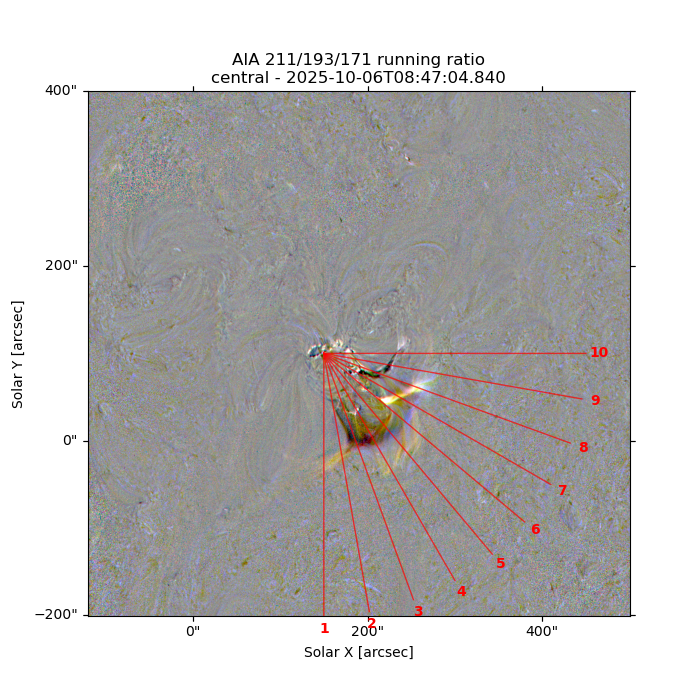

In [66]:
# Pick the sequence frame whose time is nearest REF_DATETIME.
ref_key = min(results['frames'],
              key=lambda k: abs(pd.to_datetime(k) - pd.to_datetime(REF_DATETIME)))
frame = results['frames'][ref_key]

savepath = os.path.join(FIG_DIR, f'rgb_slits_{REGION}.png') if SAVE_FIGS else None
plot_rgb_with_slits(
    frame['rgb'], frame['ref_map'], slits=results['slits'],
    title=f'AIA 211/193/171 running ratio\n{REGION} - {frame["frame_times"]["G"]}',
    show_title=SHOW_TITLES, savepath=savepath, dpi=FIG_DPI)
plt.show()

### 3. Trace a feature on each slit

Run the cell below **once** to create the shared stores, then run the interactive
cell repeatedly: set `ACTIVE_SLIT_ID`, click out `N_REPEATS` traces, change the id,
repeat. Re-running the store cell wipes previous clicks.


In [ ]:
sorted(all_kin.items(), key=lambda kv: kv[1]['x_time_num'][0])

In [81]:
clicked_traces = {}
jplot_times_by_slit = {}

Left click = add point.
Right click = save this trace and reset.


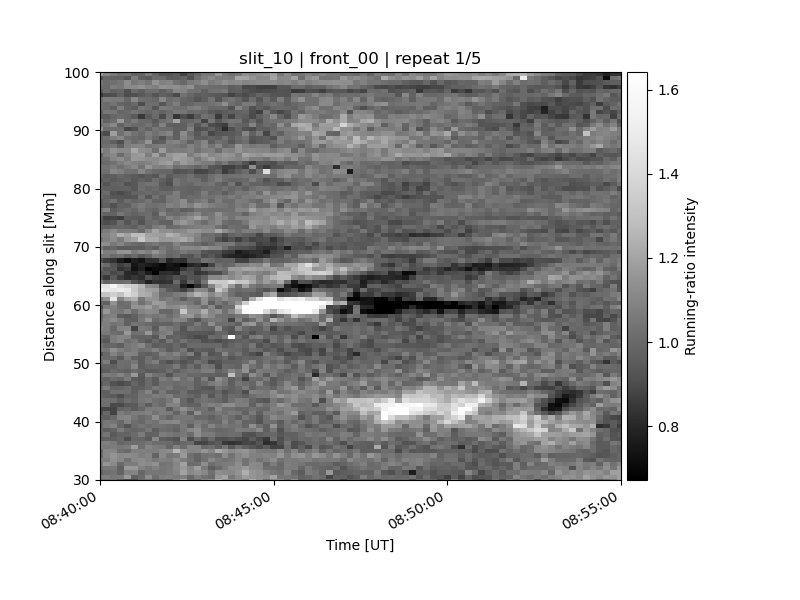

In [110]:
ACTIVE_SLIT_ID = 'slit_10'   # 1-based ids (slit_01 ... slit_NN); re-run per slit

fig, ax, jplot, jtimes, distances = plot_jplot(
    results, slit_id=ACTIVE_SLIT_ID, channel=CHANNEL,
    distance_unit=DISTANCE_UNIT, xlim=JPLOT_TLIM, ylim=JPLOT_DLIM, cmap=JPLOT_CMAP,
    show_title=SHOW_TITLES)

clicked_traces = collect_repeated_jplot_traces(
    fig, ax, slit_id=ACTIVE_SLIT_ID, feature_id=FEATURE_ID,
    n_repeats=N_REPEATS, storage=clicked_traces, y_unit=DISTANCE_UNIT,
    show_title=SHOW_TITLES)

jplot_times_by_slit[ACTIVE_SLIT_ID] = jtimes
plt.show()

### 4. Inspect the active slit (optional)

Overlay the mean trace on its J-plot and show the kinematics for whichever slit
`ACTIVE_SLIT_ID` currently points at.


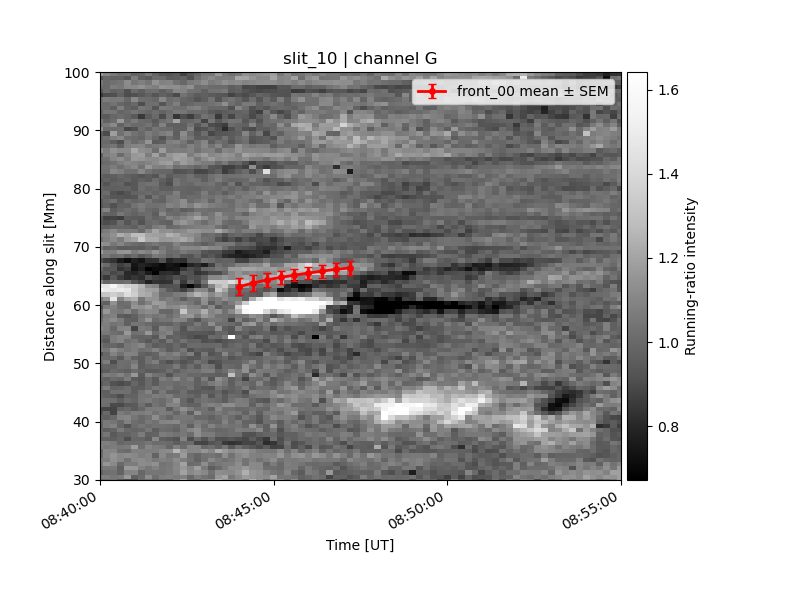

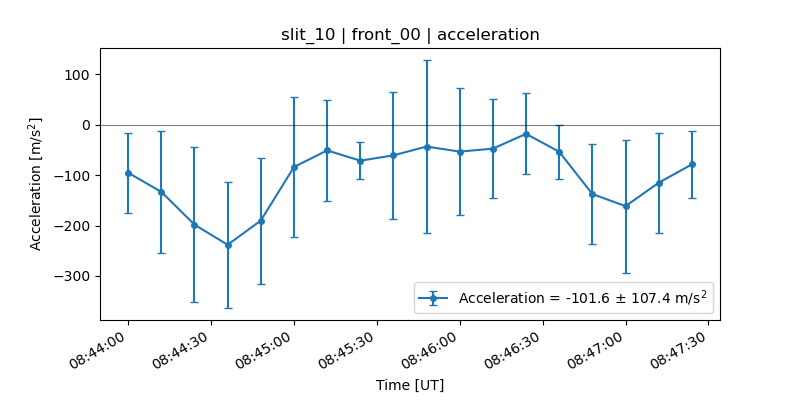

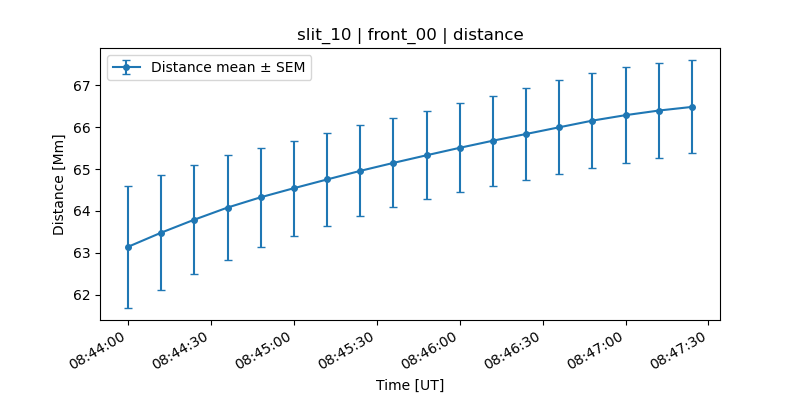

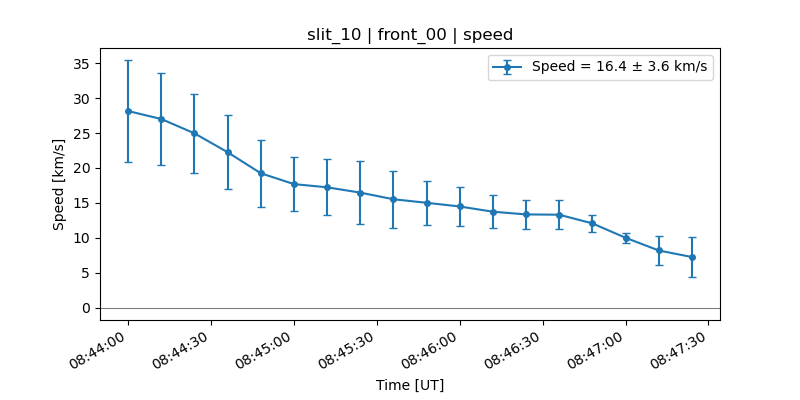

In [111]:
trace_summary = summarise_repeated_traces(
    clicked_traces, slit_id=ACTIVE_SLIT_ID, feature_id=FEATURE_ID,
    jplot_times=jplot_times_by_slit[ACTIVE_SLIT_ID])

fig, ax, *_ = plot_jplot(
    results, slit_id=ACTIVE_SLIT_ID, channel=CHANNEL,
    distance_unit=DISTANCE_UNIT, xlim=JPLOT_TLIM, ylim=JPLOT_DLIM, cmap=JPLOT_CMAP,
    show_title=SHOW_TITLES)
overplot_trace_summary(ax, trace_summary, errorbar_every=2)
if SAVE_FIGS:
    save_fig(fig, os.path.join(FIG_DIR, f'{ACTIVE_SLIT_ID}_{FEATURE_ID}_jplot.png'), dpi=FIG_DPI)
plt.show()

kin = compute_trace_kinematics(
    trace_summary, smooth=True,
    savgol_window=SAVGOL_WINDOW, savgol_polyorder=SAVGOL_POLYORDER)
kin_prefix = os.path.join(FIG_DIR, f'{ACTIVE_SLIT_ID}_{FEATURE_ID}') if SAVE_FIGS else None
plot_trace_kinematics(kin, errorbar_every=1, show_title=SHOW_TITLES,
                      savepath_prefix=kin_prefix, dpi=FIG_DPI)
plt.show()

# Optional per-slit trace-summary CSV:
trace_summary_to_dataframe(trace_summary).to_csv(
    os.path.join(OUTPUT_DIR, f'{ACTIVE_SLIT_ID}_{FEATURE_ID}_trace_summary.csv'), index=False)

In [ ]:
# # In case you want to redo a slit
# clicked_traces.pop('slit_07')
# jplot_times_by_slit.pop('slit_07')

### 5. Aggregate every traced slit, save, and plot

Operates on whatever slits exist in `clicked_traces`, so it scales from one slit
to the whole fan without edits.


In [112]:
traced_slit_ids = list(clicked_traces.keys())

all_kin = compute_kinematics_for_slits(
    clicked_traces=clicked_traces,
    slit_ids=traced_slit_ids,
    feature_id=FEATURE_ID,
    jplot_times_by_slit=jplot_times_by_slit,
    smooth=True, savgol_window=SAVGOL_WINDOW, savgol_polyorder=SAVGOL_POLYORDER)

# One CSV per slit.
for s in all_kin:
    slit_csv = os.path.join(OUTPUT_DIR, f'{s}_{FEATURE_ID}_kinematics.csv')
    kinematics_to_dataframe(all_kin[s]).to_csv(slit_csv, index=False)
    print(f'Saved {slit_csv}')

# Combined CSV (all slits stacked).
df_all_kin = pd.concat([kinematics_to_dataframe(all_kin[s]) for s in all_kin],
                       ignore_index=True)
out_csv = os.path.join(OUTPUT_DIR, f'all_slits_{FEATURE_ID}_kinematics.csv')
df_all_kin.to_csv(out_csv, index=False)
print(f'Saved {out_csv}')
df_all_kin.head()

Saved ./outputs/slit_03_front_00_kinematics.csv
Saved ./outputs/slit_02_front_00_kinematics.csv
Saved ./outputs/slit_01_front_00_kinematics.csv
Saved ./outputs/slit_04_front_00_kinematics.csv
Saved ./outputs/slit_05_front_00_kinematics.csv
Saved ./outputs/slit_06_front_00_kinematics.csv
Saved ./outputs/slit_07_front_00_kinematics.csv
Saved ./outputs/slit_08_front_00_kinematics.csv
Saved ./outputs/slit_09_front_00_kinematics.csv
Saved ./outputs/slit_10_front_00_kinematics.csv
Saved ./outputs/all_slits_front_00_kinematics.csv


,slit_id,feature_id,n_repeats,time,time_num,t_seconds,distance_mean_Mm,distance_std_Mm,distance_sem_Mm,speed_mean_km/s,speed_std_km/s,speed_sem_km/s,acceleration_mean_m/s$^2$,acceleration_std_m/s$^2$,acceleration_sem_m/s$^2$
0,slit_03,front_00,5,2025-10-06 08:41:24+00:00,20367.362083,0.0,56.385772,0.806541,0.360696,21.204640,6.447195,2.883273,135.181227,176.332378,78.858237
1,slit_03,front_00,5,2025-10-06 08:41:36+00:00,20367.362222,12.0,56.640227,0.800305,0.357907,22.826815,6.920728,3.095044,132.021102,250.649054,112.093665
2,slit_03,front_00,5,2025-10-06 08:41:48+00:00,20367.362361,24.0,56.933615,0.793776,0.354988,24.373146,9.347081,4.180142,349.732737,388.087813,173.558146
3,slit_03,front_00,5,2025-10-06 08:42:00+00:00,20367.362500,36.0,57.225183,0.775973,0.347026,31.220400,12.829066,5.737333,1022.859779,656.863714,293.758383
4,slit_03,front_00,5,2025-10-06 08:42:12+00:00,20367.362639,48.0,57.682905,0.881649,0.394286,48.921781,19.117098,8.549426,1629.122572,548.400940,245.252356


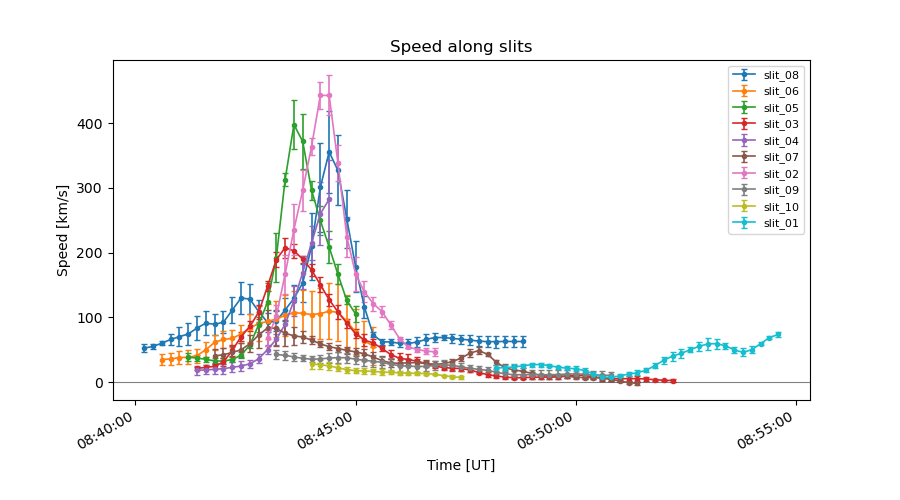

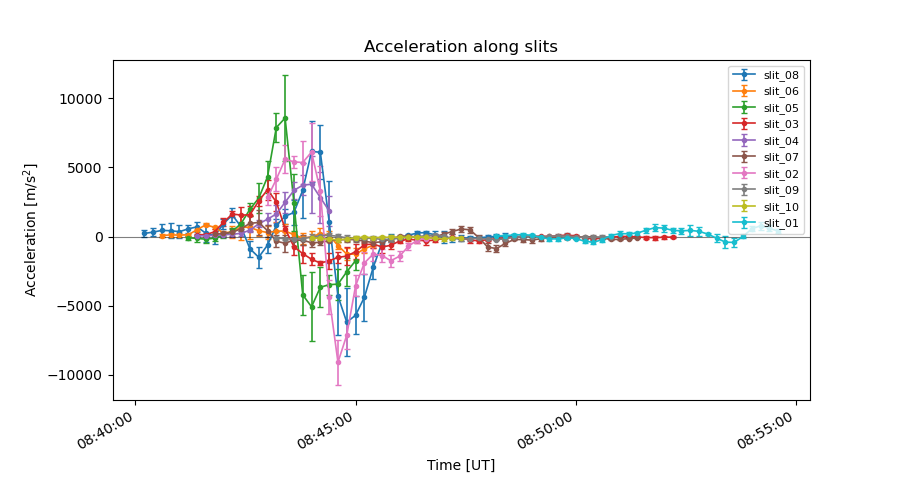

In [113]:
sp_speed = os.path.join(FIG_DIR, f'all_slits_{FEATURE_ID}_speed.png') if SAVE_FIGS else None
sp_acc   = os.path.join(FIG_DIR, f'all_slits_{FEATURE_ID}_acceleration.png') if SAVE_FIGS else None

plot_all_slit_speeds(all_kin, errorbar_every=1, show_title=SHOW_TITLES, savepath=sp_speed, dpi=FIG_DPI)
plt.show()

plot_all_slit_accelerations(all_kin, errorbar_every=1, show_title=SHOW_TITLES, savepath=sp_acc, dpi=FIG_DPI)
plt.show()